# Prepare data for single chromosome experiment

We select data progressively

1. Only reads intersecting with DMRs with average coverage in the read region >+ 40 reads.
2. First pair of fails is used for training with train/valid/test split 60/20/20
3. Other four pairs are used for testing


Import libraries and define sources

In [21]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
source = "X:/sytodata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/"
source_normal = source + "normal/"
source_tumor = source + "tumor/"
normal_parquet_files = [source_normal + x for x in os.listdir(source_normal)]
tumour_parquet_files = [source_tumor + x for x in os.listdir(source_tumor)]

Loading and processing data

In [3]:
def load_and_filter_data(
    parquet_file_path,
    target_chromosome,
    overlapping_with_dmrs="true",
    minimal_coverage=40,
):
    data = pd.read_parquet(
        parquet_file_path,
        filters=[
            ("chromosome", "==", target_chromosome),
            ("overlapping_with_dmrs", "==", overlapping_with_dmrs),
        ],
    )
    data["original_file"] = parquet_file_path.split("/")[-1]
    label = 0 if parquet_file_path.split("/")[-2] == "normal" else 1
    data["label"] = label
    data.rename(
        columns={"seq": "input_ids", "methylation_encoding": "methylation_ids"},
        inplace=True,
    )
    if "coverage" in data.columns:
        return data.loc[data["coverage"] >= minimal_coverage,]
    return data

In [4]:
def process_ang_generate_datasets(normal_parquet_files, tumour_parquet_files):
    list_of_chromosomes = ["chr" + str(x) for x in range(1, 23)]
    for chr in list_of_chromosomes:
        all_data = [
            load_and_filter_data(file, chr)
            for file in set(normal_parquet_files).union(tumour_parquet_files)
        ]
        all_data = pd.concat(all_data)
        first_pair_data = all_data.loc[
            (all_data["original_file"] == "COLO829BL_1.bam")
            | (all_data["original_file"] == "COLO829_1.bam"),
        ]
        rest_data = all_data.loc[
            (all_data["original_file"] != "COLO829BL_1.bam")
            & (all_data["original_file"] != "COLO829_1.bam"),
        ]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=1238594)
        train_index, test_index = next(
            sss.split(first_pair_data, first_pair_data[["label"]])
        )
        train_data = first_pair_data.iloc[train_index]
        test_data = first_pair_data.iloc[test_index]
        sss_valid = StratifiedShuffleSplit(
            n_splits=1, test_size=0.25, random_state=1238594
        )
        train_index, valid_index = next(
            sss_valid.split(train_data, train_data[["label"]])
        )
        valid_data = train_data.iloc[valid_index]
        train_data = train_data.iloc[train_index]
        print(
            chr,
            " Train data shape: ",
            train_data.shape,
            f"Fraction of tumor labels: {np.mean(train_data["label"]==1):.2f}",
        )
        print(
            chr,
            " Valid data shape: ",
            valid_data.shape,
            f"Fraction of tumor labels: {np.mean(valid_data["label"]==1):.2f}",
        )
        print(
            chr,
            " Test data shape: ",
            test_data.shape,
            f"Fraction of tumor labels: {np.mean(test_data["label"]==1):.2f}",
        )
        print(
            chr,
            " Rest data shape: ",
            rest_data.shape,
            f"Fraction of tumor labels: {np.mean(rest_data["label"]==1):.2f}",
        )
        save_path = f"../Data/Curated/rrms_dmrs_only_mincov40_corrected/{chr}/"
        if not os.path.exists(save_path):
            os.mkdir(save_path)
        train_data.to_parquet(save_path + "/train.parquet", index=False)
        test_data.to_parquet(save_path + "/test.parquet", index=False)
        valid_data.to_parquet(save_path + "/valid.parquet", index=False)
        rest_data.to_parquet(save_path + "/rest.parquet", index=False)

In [5]:
# process_ang_generate_datasets(normal_parquet_files,tumour_parquet_files)

## Attempt on doing better data preparation for mixed distributions

Defying split functions

In [6]:
import ast


def split_row_by_dmr_overlaps(df_row):
    """
    Split a single DataFrame row into multiple rows based on DMR overlap locations.

    Parameters:
    df_row: pandas Series or single-row DataFrame containing the methylation data

    Returns:
    pandas DataFrame with one row per DMR overlap
    """

    # Convert row to Series if it's a DataFrame
    if isinstance(df_row, pd.DataFrame):
        row = df_row.iloc[0]
    else:
        row = df_row

    # Parse overlap_locations if it's a string
    overlap_locations = row["overlap_locations"]
    if isinstance(overlap_locations, str):
        overlap_locations = ast.literal_eval(overlap_locations)

    # Parse overlap_names if it's a string
    overlap_names = row["overlap_names"]
    if isinstance(overlap_names, str):
        overlap_names = ast.literal_eval(overlap_names)

    # Parse dmr_types if it's a string
    dmr_types = row["dmr_types"]
    if isinstance(dmr_types, str):
        dmr_types = ast.literal_eval(dmr_types)

    # Parse areastats if it's a string
    areastats = row["areastats"]
    if isinstance(areastats, str):
        areastats = ast.literal_eval(areastats)

    # Get original sequences
    input_ids = row["input_ids"]
    methylation_ids = row["methylation_ids"]
    read_start = row["read_start"]

    new_rows = []

    for i, (start, end) in enumerate(overlap_locations):
        # Calculate relative positions within the read
        rel_start = start - read_start
        rel_end = end - read_start

        # Ensure we don't go beyond sequence boundaries
        rel_start = max(0, rel_start)
        rel_end = min(len(input_ids), rel_end)

        # Extract overlapping sequences
        overlap_input_ids = input_ids[rel_start:rel_end]
        overlap_methylation_ids = methylation_ids[rel_start:rel_end]

        # Calculate new statistics
        overlap_length = len(overlap_input_ids)
        overlap_sequence_length = (
            overlap_length  # Same as overlap_length for this segment
        )

        # Count CpGs and methylation in the overlap
        total_cpgs = overlap_methylation_ids.count("1") + overlap_methylation_ids.count(
            "0"
        )
        methylated_cpgs = overlap_methylation_ids.count("1")
        unmethylated_cpgs = overlap_methylation_ids.count("0")
        methylation_rate = methylated_cpgs / total_cpgs if total_cpgs > 0 else 0.0

        if "coverage" in row.keys():
            coverage = row["coverage"]
        else:
            coverage = None

        # Create new row
        new_row = {
            # Preserved original fields
            "read_name": row["read_name"],
            "original_file": row["original_file"],
            "label": row["label"],
            # Updated sequences
            "input_ids": overlap_input_ids,
            "methylation_ids": overlap_methylation_ids,
            # Updated coordinates
            "read_start": start,
            "read_end": end,
            "read_length": end - start,
            "sequence_length": overlap_sequence_length,
            # Recomputed methylation stats
            "total_cpgs": total_cpgs,
            "methylated_cpgs": methylated_cpgs,
            "unmethylated_cpgs": unmethylated_cpgs,
            "methylation_rate": methylation_rate,
            # Preserved technical fields
            "mapping_quality": row["mapping_quality"],
            "is_reverse": row["is_reverse"],
            "coverage": coverage,
            "chromosome": row["chromosome"],
            # Gene overlap info (preserved as-is, could be recomputed if needed)
            "overlapping_with_genes": row["overlapping_with_genes"],
            "overlapping_genes_count": row["overlapping_genes_count"],
            "overlapping_genes_list": row["overlapping_genes_list"],
            "overlapping_oncogenes": row["overlapping_oncogenes"],
            "overlapping_tumor_suppressors": row["overlapping_tumor_suppressors"],
            "max_gene_overlap_percentage": row["max_gene_overlap_percentage"],
            "max_occurrence_count": row["max_occurrence_count"],
            "has_oncogene": row["has_oncogene"],
            "has_tumor_suppressor": row["has_tumor_suppressor"],
            # DMR-specific info for this overlap
            "overlapping_dmrs_count": 1,  # Each new row represents one DMR
            "overlapping_dmrs_bps": end - start,
            "max_dmr_overlap_percentage": 100.0,  # 100% overlap since we're cutting exactly at DMR boundaries
            "overlapping_with_dmrs": True,
            # DMR details for this specific overlap
            "dmr_name": overlap_names[i] if i < len(overlap_names) else f"DMR_{i}",
            "dmr_type": dmr_types[i] if i < len(dmr_types) else "Unknown",
            "areastat": areastats[i] if i < len(areastats) else 0.0,
            "overlap_start": start,
            "overlap_end": end,
        }

        new_rows.append(new_row)

    return pd.DataFrame(new_rows)


# Example usage function
def process_dataframe_with_dmr_splits(df):
    """
    Process an entire DataFrame, splitting rows that have DMR overlaps.

    Parameters:
    df: pandas DataFrame with methylation data

    Returns:
    pandas DataFrame with split rows
    """
    all_split_rows = []

    for idx, row in df.iterrows():
        # Check if row has DMR overlaps
        if row["overlapping_with_dmrs"] and row["overlapping_dmrs_count"] > 0:
            split_rows = split_row_by_dmr_overlaps(row)
            all_split_rows.append(split_rows)
        else:
            # Keep original row if no DMR overlaps
            all_split_rows.append(pd.DataFrame([row]))

    # Concatenate all split rows
    result_df = pd.concat(all_split_rows, ignore_index=True)
    return result_df

In [11]:
def process_ang_generate_selective_datasets(normal_parquet_files, tumour_parquet_files):
    list_of_chromosomes = ["chr" + str(x) for x in range(1, 23)]
    dmrs_df = pd.read_csv(
        "../../../R/dmrs_with_merged_genes_25_smoothing_pdmr0.0001_pimr0.01_minlen500.csv"
    )
    dmrs_df = pd.concat(
        [
            dmrs_df.loc[dmrs_df["type"] == "DMR-Hypo"][:1500],
            dmrs_df.loc[dmrs_df["type"] == "DMR-Hyper"][:1500],
        ]
    )
    for chr in list_of_chromosomes:
        all_data = [
            load_and_filter_data(file, chr, minimal_coverage=40)
            for file in set(normal_parquet_files).union(tumour_parquet_files)
        ]
        all_data = pd.concat(all_data)
        selected_data = all_data.loc[all_data["overlapping_dmrs_bps"] >= 500]
        dmrs_current_list = dmrs_df.loc[dmrs_df["chr"] == chr]
        dmrs_current_list = dmrs_current_list["name"].to_numpy()
        selected_data["good_dmrs"] = selected_data["overlap_names"].apply(
            lambda x: any(item in dmrs_current_list for item in x)
        )
        selected_data_filtered = selected_data.loc[selected_data["good_dmrs"] == 1]
        selected_data_dmrs = process_dataframe_with_dmr_splits(selected_data_filtered)
        selected_data_dmrs["good_dmrs"] = selected_data_dmrs["dmr_name"].apply(
            lambda x: x in dmrs_current_list
        )
        good_dmrs_data = selected_data_dmrs.loc[selected_data_dmrs["good_dmrs"] == 1]
        good_dmrs_data = good_dmrs_data.loc[
            good_dmrs_data["overlapping_dmrs_bps"] >= 500
        ]
        train_data = good_dmrs_data.loc[
            (good_dmrs_data["original_file"] == "COLO829BL_1.bam")
            | (good_dmrs_data["original_file"] == "COLO829_1.bam")
            | (good_dmrs_data["original_file"] == "COLO829BL_2.bam")
            | (good_dmrs_data["original_file"] == "COLO829_2.bam")
            | (good_dmrs_data["original_file"] == "COLO829BL_3.bam")
            | (good_dmrs_data["original_file"] == "COLO829_3.bam")
        ]
        valid_data = good_dmrs_data.loc[
            (good_dmrs_data["original_file"] == "COLO829BL_4.bam")
            | (good_dmrs_data["original_file"] == "COLO829_4.bam"),
        ]
        test_data = good_dmrs_data.loc[
            (good_dmrs_data["original_file"] == "COLO829BL_5.bam")
            | (good_dmrs_data["original_file"] == "COLO829_5.bam"),
        ]

        whole_reads_top_3000 = selected_data_filtered.loc[
            (selected_data_filtered["original_file"] == "COLO829BL_5.bam")
            | (selected_data_filtered["original_file"] == "COLO829_5.bam"),
        ]

        print(
            chr,
            " Train data shape: ",
            train_data.shape,
            f"Fraction of tumor labels: {np.mean(train_data["label"]==1):.2f}",
        )
        print(
            chr,
            " Valid data shape: ",
            valid_data.shape,
            f"Fraction of tumor labels: {np.mean(valid_data["label"]==1):.2f}",
        )
        print(
            chr,
            " Test data shape: ",
            test_data.shape,
            f"Fraction of tumor labels: {np.mean(test_data["label"]==1):.2f}",
        )
        print(
            chr,
            " Whole reads test data shape: ",
            whole_reads_top_3000.shape,
            f"Fraction of tumor labels: {np.mean(whole_reads_top_3000["label"]==1):.2f}",
        )

        save_path = (
            f"../Data/Curated/rrms_dmrs_only_mincov40_corrected_top3000_dmr_cuts/{chr}/"
        )
        if not os.path.exists(save_path):
            os.mkdir(save_path)
        train_data.to_parquet(save_path + "/train.parquet", index=False)
        test_data.to_parquet(save_path + "/test.parquet", index=False)
        valid_data.to_parquet(save_path + "/valid.parquet", index=False)
        whole_reads_top_3000.to_parquet(
            save_path + "/test_whole_reads.parquet", index=False
        )
        # return train_data, valid_data, test_data

In [12]:
process_ang_generate_selective_datasets(normal_parquet_files, tumour_parquet_files)

C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_31936\2764816847.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data["good_dmrs"] = selected_data["overlap_names"].apply(lambda x: any(item in dmrs_current_list for item in x))


chr1  Train data shape:  (285528, 36) Fraction of tumor labels: 0.59
chr1  Valid data shape:  (88074, 36) Fraction of tumor labels: 0.59
chr1  Test data shape:  (101848, 36) Fraction of tumor labels: 0.61
chr1  Whole reads test data shape:  (98463, 38) Fraction of tumor labels: 0.61


C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_31936\2764816847.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data["good_dmrs"] = selected_data["overlap_names"].apply(lambda x: any(item in dmrs_current_list for item in x))


chr2  Train data shape:  (50058, 36) Fraction of tumor labels: 0.59
chr2  Valid data shape:  (14479, 36) Fraction of tumor labels: 0.64
chr2  Test data shape:  (18503, 36) Fraction of tumor labels: 0.63
chr2  Whole reads test data shape:  (12841, 38) Fraction of tumor labels: 0.59


C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_31936\2764816847.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data["good_dmrs"] = selected_data["overlap_names"].apply(lambda x: any(item in dmrs_current_list for item in x))


...

chr20  Train data shape:  (20821, 36) Fraction of tumor labels: 0.78
chr20  Valid data shape:  (7266, 36) Fraction of tumor labels: 0.85
chr20  Test data shape:  (7762, 36) Fraction of tumor labels: 0.82
chr20  Whole reads test data shape:  (7214, 38) Fraction of tumor labels: 0.83


C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_31936\2764816847.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data["good_dmrs"] = selected_data["overlap_names"].apply(lambda x: any(item in dmrs_current_list for item in x))


chr21  Train data shape:  (301265, 36) Fraction of tumor labels: 0.54
chr21  Valid data shape:  (97274, 36) Fraction of tumor labels: 0.56
chr21  Test data shape:  (105012, 36) Fraction of tumor labels: 0.55
chr21  Whole reads test data shape:  (74702, 38) Fraction of tumor labels: 0.55


C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_31936\2764816847.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data["good_dmrs"] = selected_data["overlap_names"].apply(lambda x: any(item in dmrs_current_list for item in x))


chr22  Train data shape:  (21033, 36) Fraction of tumor labels: 0.75
chr22  Valid data shape:  (7453, 36) Fraction of tumor labels: 0.83
chr22  Test data shape:  (7624, 36) Fraction of tumor labels: 0.78
chr22  Whole reads test data shape:  (7298, 38) Fraction of tumor labels: 0.79


In [48]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def cohen_d(group1, group2):
    """
    Computes Cohen's d to measure effect size between two distributions.
    Implemented based on ConceptsOfBiometrics.pdf, slide 77.

    Parameters:
    - group1, group2: Arrays of numerical values.

    Returns:
    - Cohen's d value (effect size).
    """
    mean1, mean2 = np.mean(group1), np.mean(group2)
    n1, n2 = len(group1), len(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)  # Unbiased std
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    return abs((mean1 - mean2)) / pooled_std


def plot_filled_kde(values, groups, alpha=0.4, ax=None, bw_adjust=0.4, name="Default"):
    """
    Plots overlapping KDE (Kernel Density Estimation) curves with filled areas for two groups (0 and 1).
    Also computes Cohen's d to measure effect size.

    Parameters:
    - values: A list or numpy array of numerical values.
    - groups: A list or numpy array of group labels (0 or 1).
    - alpha: Transparency level for the filled area under KDE curves (default is 0.4).
    - ax: Matplotlib axis to plot on (optional).
    """
    # Convert to numpy arrays
    values = np.array(values)
    groups = np.array(groups)

    # Ensure groups contain only 0s and 1s
    unique_groups = np.unique(groups)
    if len(unique_groups) > 2 or set(unique_groups) - {0, 1}:
        raise ValueError("Groups should contain only 0 and 1.")

    # Separate values by group
    values_0 = values[groups == 0]  # Impostor scores
    values_1 = values[groups == 1]  # Genuine scores

    # Compute Uniquness and permanence
    uniqueness = np.abs(np.mean(values_0) - np.mean(values_1))

    n1, n2 = len(values_0), len(values_1)
    std1, std2 = np.std(values_0, ddof=1), np.std(values_1, ddof=1)  # Unbiased std
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    d_value = cohen_d(values_0, values_1)
    # permanence = pooled_std

    # If no axis is provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # KDE plots with filled area
    sns.kdeplot(
        values_0,
        color="blue",
        fill=True,
        alpha=alpha,
        label="Normal Distribution",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )
    sns.kdeplot(
        values_1,
        color="red",
        fill=True,
        alpha=alpha,
        label="Tumour Distribution",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )

    # Labels and legend
    ax.set_xlabel("Methylation")
    ax.set_ylabel("Density")
    ax.set_title(
        f"{name} \n Means Difference: {uniqueness:.3f}, \n Pooled StDev: {pooled_std:.3f}"
    )
    ax.legend()
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.6)

    # If ax is None, show the plot
    if ax is None:
        plt.show()

In [23]:
path = "../Data/Curated/rrms_dmrs_only_mincov40_corrected_top3000_dmr_cuts/chr19"
train_data = pd.read_parquet(path + "/train.parquet")

In [49]:
import matplotlib

font = {"family": "Verdana", "weight": "regular", "size": 28}

matplotlib.rc("font", **font)

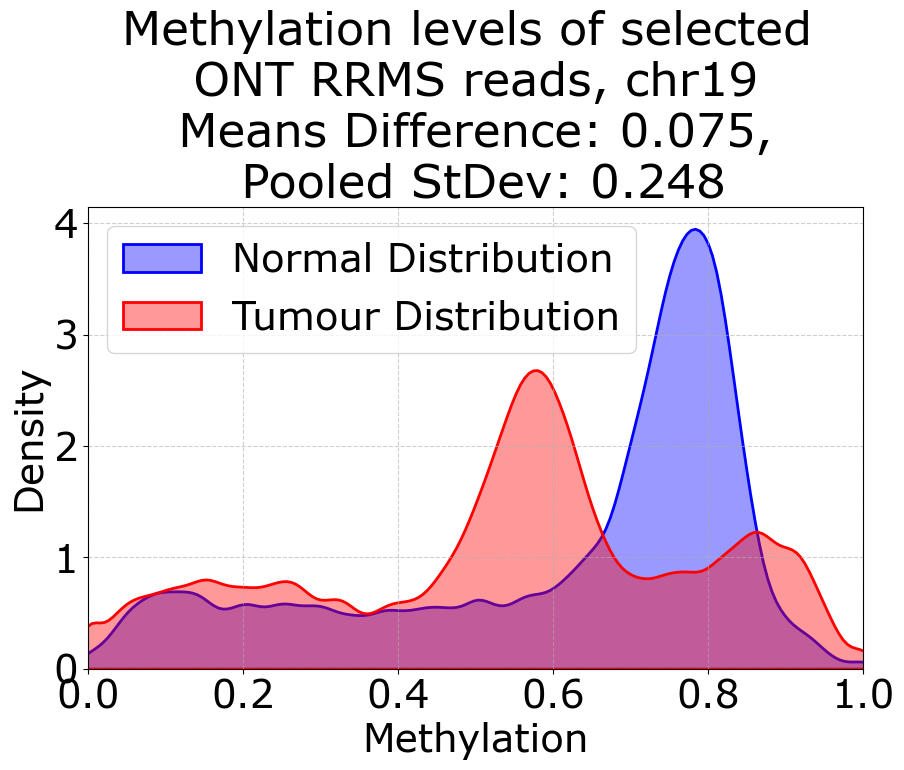

In [50]:
plot_filled_kde(
    scores, id, name="Methylation levels of selected \n ONT RRMS reads, chr19"
)

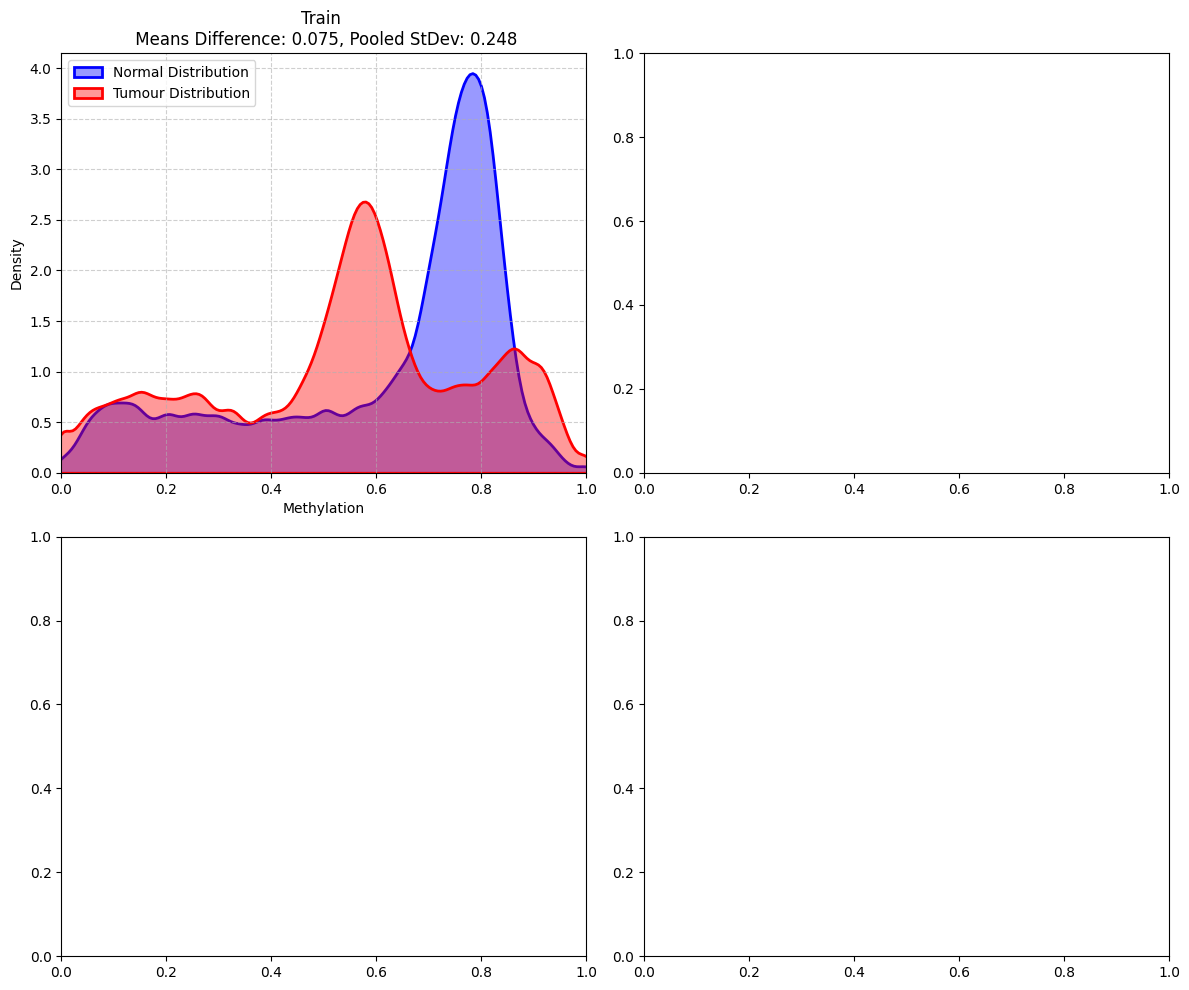

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # Adjust figure size if needed
axes = axes.ravel()  # Flatten the 2D array of axes for easy iteration

# Iterate over the systems and plot in the respective subplot
for i, (scores, id, name) in enumerate(
    [
        (train_data["methylation_rate"], train_data["label"], "Train"),
        # (valid_data["methylation_rate"], valid_data["label"], "Valid"),
        # (test_data["methylation_rate"], test_data["label"], "Test"),
    ]
):
    plot_filled_kde(
        scores, id, ax=axes[i], name=name
    )  # Pass the corresponding subplot axis

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [1]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))  # Adjust figure size if needed
axes = axes.ravel()  # Flatten the 2D array of axes for easy iteration

for i in range(1, 6, 1):
    sub = good_dmrs_data.loc[
        (good_dmrs_data["original_file"] == f"COLO829BL_{i}.bam")
        | (good_dmrs_data["original_file"] == f"COLO829_{i}.bam")
    ]
    # sub = sub.loc[sub["dmr_name"]=="DMR_6400"]
    plot_filled_kde(
        sub["methylation_rate"],
        sub["label"],
        ax=axes[i - 1],
        name=f"{i}, N reads: {sub.shape[0]}",
        bw_adjust=0.3,
    )  # Pass the corresponding subplot axis


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined